In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway


In [2]:
print('Running imports...')

import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib
# from models.model import get_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo
plt.style.use('robin')
# matplotlib.use('tkagg')
import seaborn as sns 
from tqdm.notebook import tqdm
import cartopy.crs as ccrs

Running imports...


In [3]:
files = glob.glob('out_data/rosendal/*')
ds1 = xr.open_mfdataset(files, combine='nested', concat_dim='n_conv_layers').assign_coords(n_conv_layers = np.arange(7)).load()
ds1[['preds','targets']] = ds1[['preds','targets']].shift(timestep=1).max('time')
ds1 = ds1.sel(timestep=range(1,5))

ds2 = ds1.sel(n_conv_layers = 2)
ds2 = ds2.where(ds2.time.dt.season=='SON', drop=True).mean('time')

In [4]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Polygon

import cartopy.crs as ccrs
import matplotlib.ticker as mticker
def clean_map(plot, boundaries=(-90, 50, 0, 90)):
    lon_min, lon_max , lat_min, lat_max = boundaries
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        ax.set_extent(boundaries, crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='-')
        gl.xlocator = mticker.FixedLocator(np.linspace(-180,180,17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(0,81,20))
        
        longitudes = np.linspace(lon_min, lon_max, 100)
        latitudes = np.linspace(lat_min, lat_max,100)
        xx = list(longitudes)[::-1]+\
                [longitudes.min() for _ in range(latitudes.size)] + \
                    list(longitudes)+\
                        [longitudes.max() for _ in range(latitudes.size)]
        yy = [latitudes.max() for _ in range(longitudes.size)] \
                + list(latitudes)[::-1]+\
                    [latitudes.min() for _ in range(longitudes.size)]+ \
                        list(latitudes)[::-1]
        verts = np.array([xx, yy]).T
        circle = Path(verts)
        ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

def clean_map_nocut(plot):
    projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        # ax.set_extent([-90, 60, 20, 80], crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='--')
        gl.xlocator = mticker.FixedLocator(np.linspace(-180,180,17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(20,81,20))
        
        # longitudes = np.linspace(-90, 60, 100)
        # latitudes = np.linspace(20,80,100)
        # xx = list(longitudes)[::-1]+\
        #         [longitudes.min() for _ in range(latitudes.size)] + \
        #             list(longitudes)+\
        #                 [longitudes.max() for _ in range(latitudes.size)]
        # yy = [latitudes.max() for _ in range(longitudes.size)] \
        #         + list(latitudes)[::-1]+\
        #             [latitudes.min() for _ in range(longitudes.size)]+ \
        #                 list(latitudes)[::-1]
        # verts = np.array([xx, yy]).T
        # circle = Path(verts)
        # ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())
    

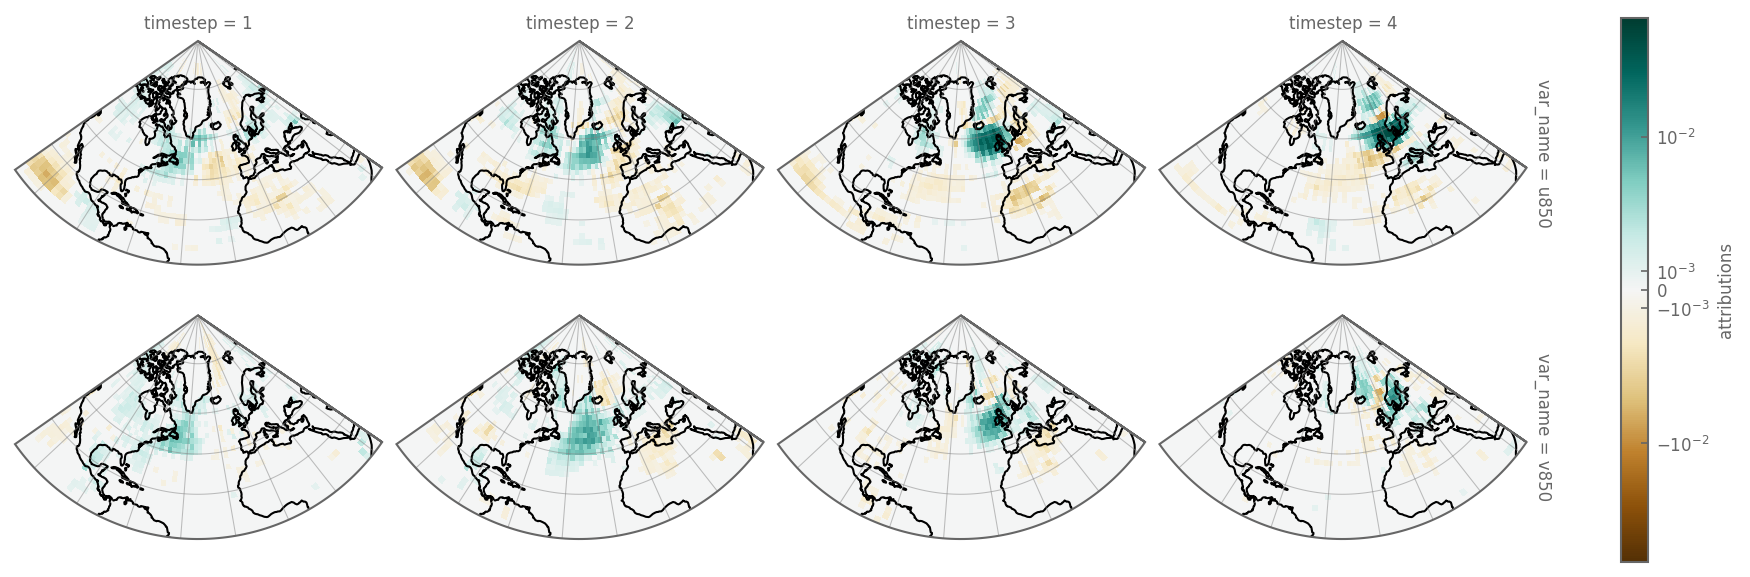

In [8]:
ds_attributions = ds2.attributions
test = ds_attributions.mean('attribution_time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test_max = test/test.max(['longitude','latitude', 'var_name'])
projection = ccrs.LambertConformal(central_longitude=-38.0, central_latitude=39.0)
# projection = ccrs.Robinson(central_longitude=-15.0)
# projection = ccrs.PlateCarree(central_longitude=-15.0)

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
test = test.where(np.abs(test)>1e-3,0)
plot = test.plot(col='timestep', row='var_name', subplot_kws = dict(projection=projection), aspect=1.5, size=2, transform=ccrs.PlateCarree(),
                 norm = matplotlib.colors.SymLogNorm(linthresh=0.002,linscale=.2), cmap='BrBG')

clean_map(plot, boundaries = (-125, 50, 0, 90))


In [6]:
ds1.attributions.max(['longitude','latitude','var_name','timestep']).groupby('attribution_time.season').count()

<xarray.DataArray 'attributions' (n_conv_layers: 7, season: 4)> Size: 224B
array([[52,  3,  7, 48],
       [28,  3,  1, 33],
       [51,  3,  3, 43],
       [49,  2,  5, 48],
       [45,  2,  7, 38],
       [60,  2,  9, 56],
       [40,  0,  6, 46]])
Coordinates:
    mask_id        int64 8B 14
  * n_conv_layers  (n_conv_layers) int64 56B 0 1 2 3 4 5 6
  * season         (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

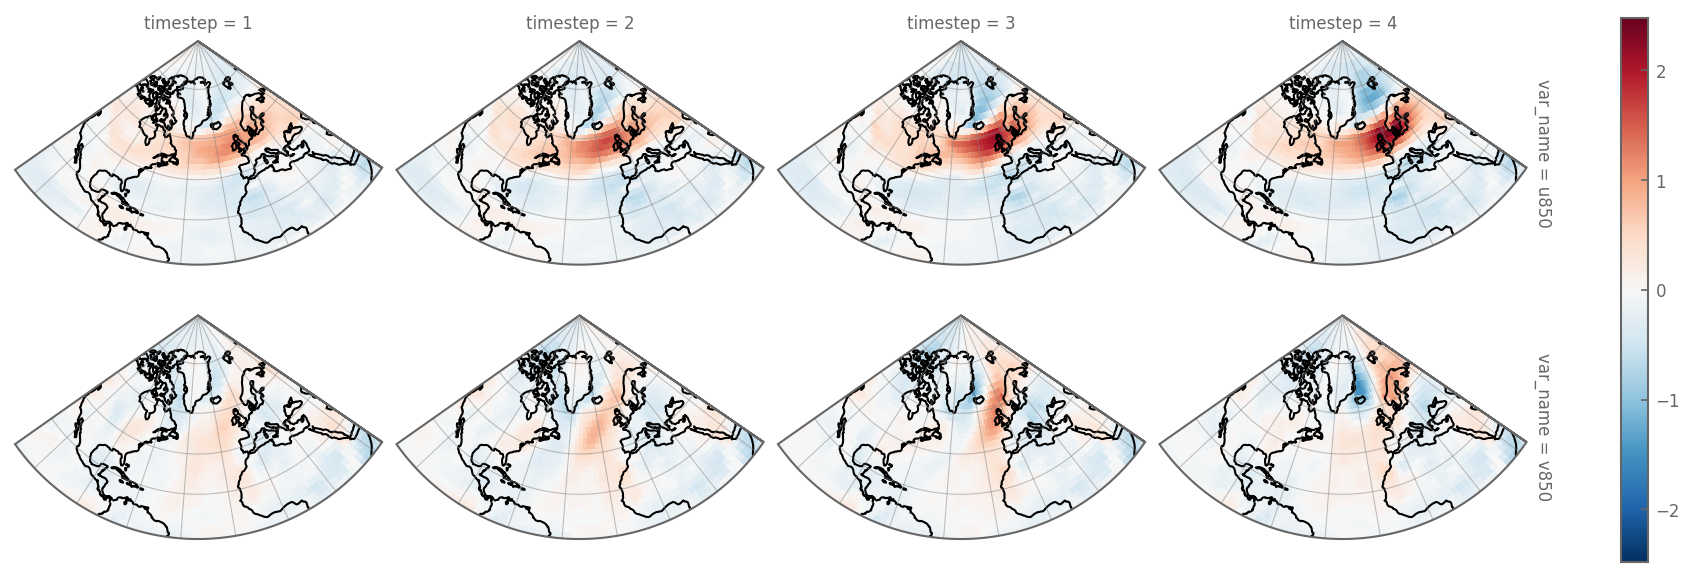

In [7]:
fields = (ds2.attributions/ds2.sensitivity).mean('attribution_time')
projection = ccrs.LambertConformal(central_longitude=-38.0, central_latitude=39.0)
# projection = ccrs.Robinson(central_longitude=-15.0)
# projection = ccrs.PlateCarree(central_longitude=-15.0)

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
# test = test.where(np.abs(test)>1e-3,0)
plot = fields.plot(col='timestep', row='var_name', subplot_kws = dict(projection=projection), aspect=1.5, size=2, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r')

clean_map(plot, boundaries = (-125, 50, 0, 90))

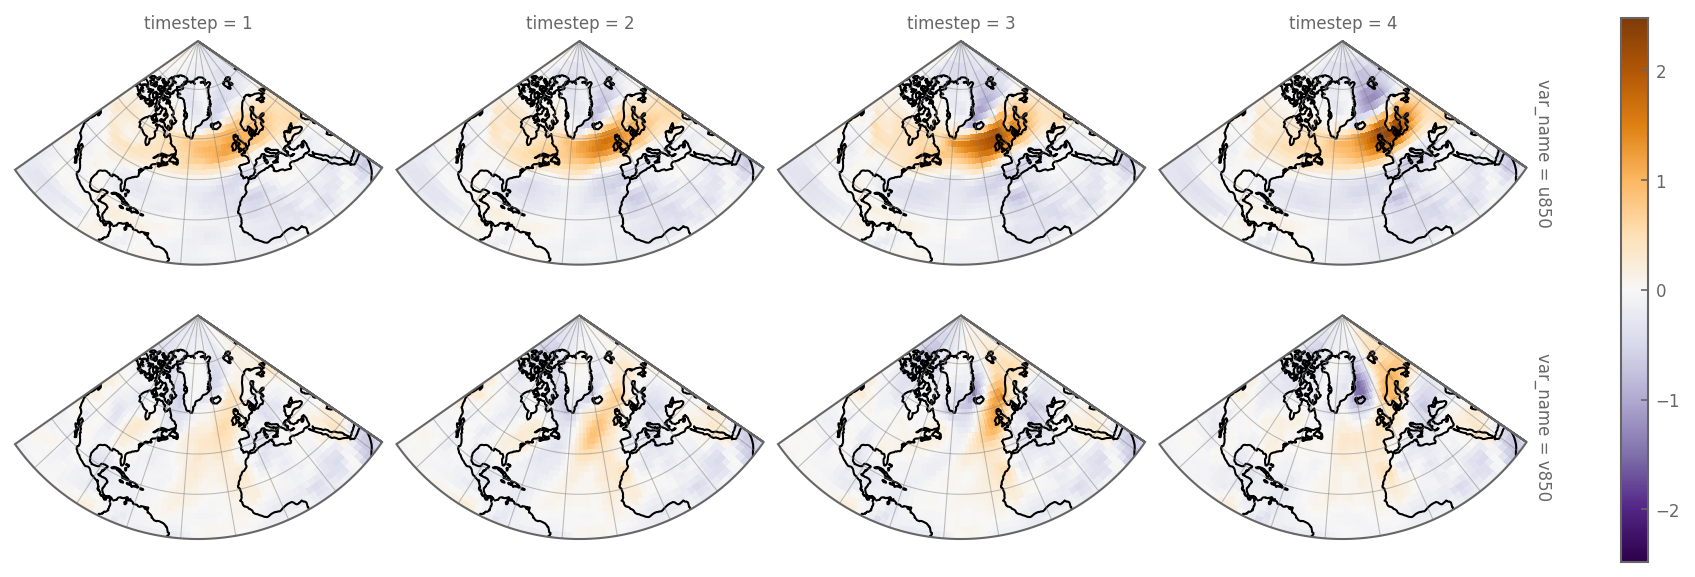

In [9]:
sens = (ds2.sensitivity).mean('attribution_time')
projection = ccrs.LambertConformal(central_longitude=-38.0, central_latitude=39.0)
# projection = ccrs.Robinson(central_longitude=-15.0)
# projection = ccrs.PlateCarree(central_longitude=-15.0)

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
# test = test.where(np.abs(test)>1e-3,0)
plot = fields.plot(col='timestep', row='var_name', subplot_kws = dict(projection=projection), aspect=1.5, size=2, transform=ccrs.PlateCarree(),
                  cmap='PuOr_r')

clean_map(plot, boundaries = (-125, 50, 0, 90))

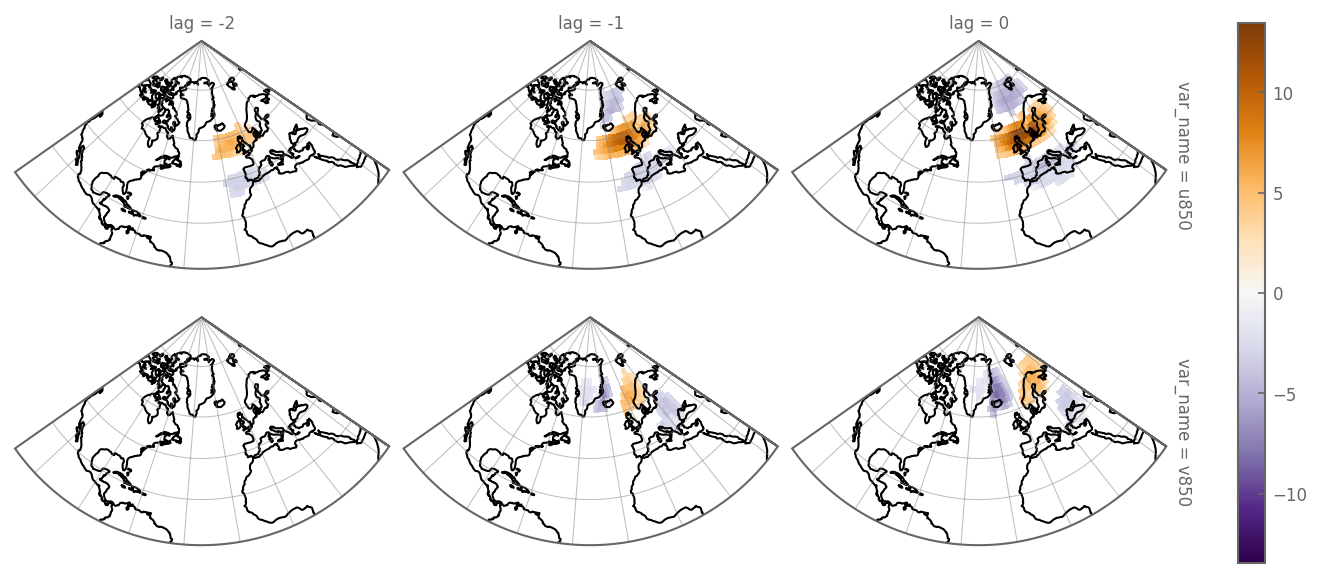

In [ ]:
josh_prec = xr.open_dataset(f"/Data/gfi/users/jodor4442/ERA5land_precursors/patterns/standard_SON_region14.nc")

josh = josh_prec[['u850','v850']].to_array('var_name').sel(lag=[-2,-1,0]).isel(index_val=1).interp_like(ds1)
projection = ccrs.LambertConformal(central_longitude=-38.0, central_latitude=39.0)
# projection = ccrs.Robinson(central_longitude=-15.0)
# projection = ccrs.PlateCarree(central_longitude=-15.0)

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
# test = test.where(np.abs(test)>1e-3,0)
plot = josh.plot(col='lag', row='var_name', subplot_kws = dict(projection=projection), aspect=1.5, size=2, transform=ccrs.PlateCarree(),
                  cmap='PuOr_r')

clean_map(plot, boundaries = (-125, 50, 0, 90))

In [13]:
ds1

<xarray.Dataset> Size: 151MB
Dimensions:           (n_conv_layers: 7, attribution_time: 165, timestep: 4,
                       var_name: 2, latitude: 32, longitude: 64, time: 4096)
Coordinates:
  * timestep          (timestep) int64 32B 1 2 3 4
  * var_name          (var_name) <U4 32B 'u850' 'v850'
  * latitude          (latitude) float64 256B 1.406 4.219 7.031 ... 85.78 88.59
  * longitude         (longitude) float64 512B -126.6 -123.8 ... 47.81 50.62
  * attribution_time  (attribution_time) datetime64[ns] 1kB 1995-09-24 ... 20...
  * time              (time) datetime64[ns] 33kB 1995-06-13 ... 2006-08-29
    mask_id           int64 8B 14
  * n_conv_layers     (n_conv_layers) int64 56B 0 1 2 3 4 5 6
Data variables:
    attributions      (n_conv_layers, attribution_time, timestep, var_name, latitude, longitude) float32 76MB ...
    sensitivity       (n_conv_layers, attribution_time, timestep, var_name, latitude, longitude) float32 76MB ...
    targets           (n_conv_layers, timestep) float64 224B 2.0 2.0 ... 2.0 2.0
    preds             (n_conv_layers, timestep) float64 224B 2.0 2.0 ... 2.0 2.0

In [5]:
(ds1.longitude.min()+ds1.longitude.max()).values/2

-37.96875

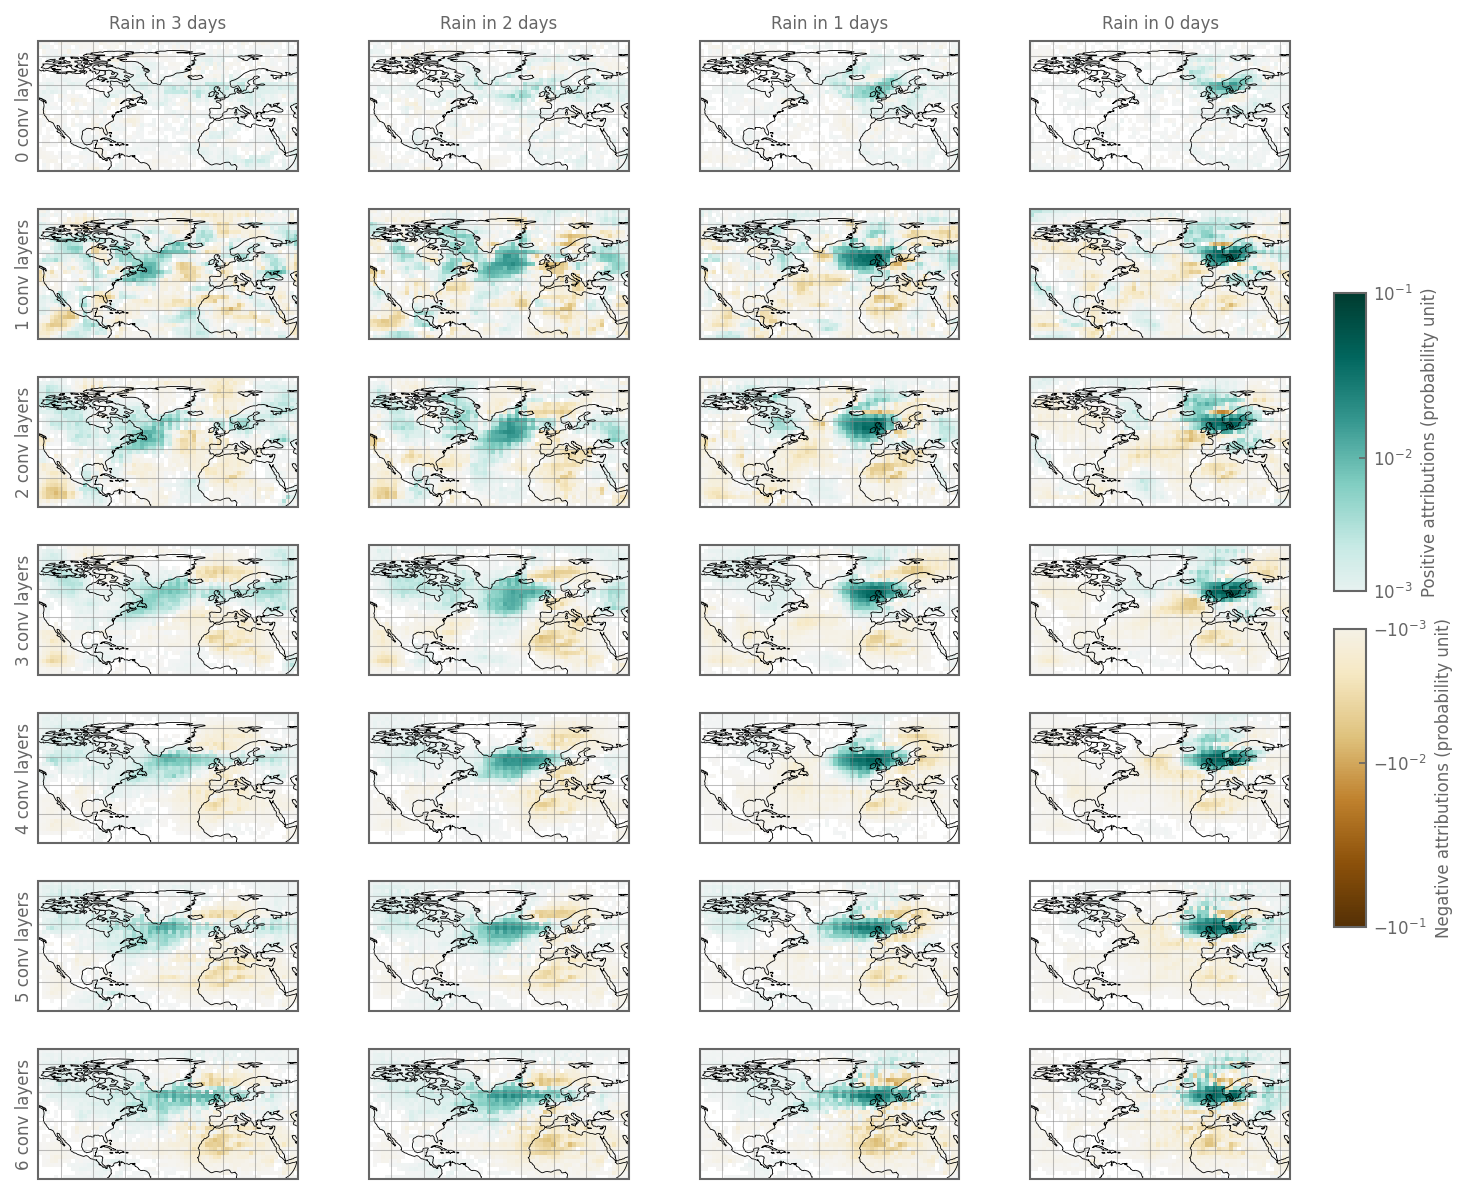

In [53]:

test = ds1.mean('attribution_time').attributions.sum('var_name')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
projection = ccrs.PlateCarree(central_longitude=-38)
mosaic = [["A0","B0","C0","D0","."],
          ["A0","B0","C0","D0","."],
          ["A1","B1","C1","D1","."],
          ["A1","B1","C1","D1","cbar1"],
          ["A2","B2","C2","D2","cbar1"],
          ["A2","B2","C2","D2","cbar1"],
          ["A3","B3","C3","D3","cbar1"],
          ["A3","B3","C3","D3","cbar2"],
          ["A4","B4","C4","D4","cbar2"],
          ["A4","B4","C4","D4","cbar2"],
          ["A5","B5","C5","D5","cbar2"],
          ["A5","B5","C5","D5","."],
          ["A6","B6","C6","D6","."],
          ["A6","B6","C6","D6","."],
]
map_kwargs = dict(projection=projection)
map_kwargs = dict(projection=projection)

per_subplot_kw = {k:map_kwargs for k in np.array(mosaic).flatten() if k not in ['cbar1','cbar2','.']}
fig, axs = plt.subplot_mosaic(mosaic,
                              figsize=(10,8),
                              width_ratios = [10,10,10,10,1],
                              per_subplot_kw=per_subplot_kw)
for t, timestep in enumerate(test.timestep):
    for c in test.n_conv_layers.values:
        ax_number = chr(ord("A")+t) + f"{c}"
        ax = axs[ax_number]
        test_extract = test.isel(timestep=t, n_conv_layers=c)
        ax_cbar = axs['cbar1'] if c<3 else axs['cbar2']
        test_extract.where(np.abs(test_extract)>0.0001).plot(ax=ax, transform=ccrs.PlateCarree(),
                                                             norm = matplotlib.colors.SymLogNorm(linthresh=0.002,linscale=.2),
                                                             cmap='BrBG', vmax=.1,
                                                             cbar_ax=ax_cbar)
        ax.set_title('')
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='-')
        gl.xlocator = mticker.FixedLocator(np.linspace(-180,180,17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(0,81,20))
        ax.coastlines(linewidth=.4)
        if t==0:
            ax.text(-0.02, 0.5, f"{c} conv layers",  ha='right', va='center',rotation='vertical', fontsize=8, transform=ax.transAxes)        
        if c==0:
            ax.set_title(f"Rain in {3-t} days", size=8)


axs['cbar1'].set_ylim(.001,.1)
axs['cbar2'].set_ylim(-.1,-.001)
axs['cbar1'].set_ylabel("Positive attributions (probability unit)")
axs['cbar2'].set_ylabel("Negative attributions (probability unit)")

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
# test = test.where(np.abs(test)>1e-3,0)
# plot = test.where(test>0).plot( col='n_conv_layers', row='timestep',
#                  subplot_kws = dict(projection=projection), aspect=1.9, size=2, transform=ccrs.PlateCarree(),
#                 #  norm = matplotlib.colors.SymLogNorm(linthresh=0.002,linscale=.2), 
#                  norm = matplotlib.colors.LogNorm(), 
#                  cmap='mako_r')

# clean_map(plot, boundaries = (-125, 50, 0, 90))
plt.tight_layout()
# test.plot(col='n_conv_layers')

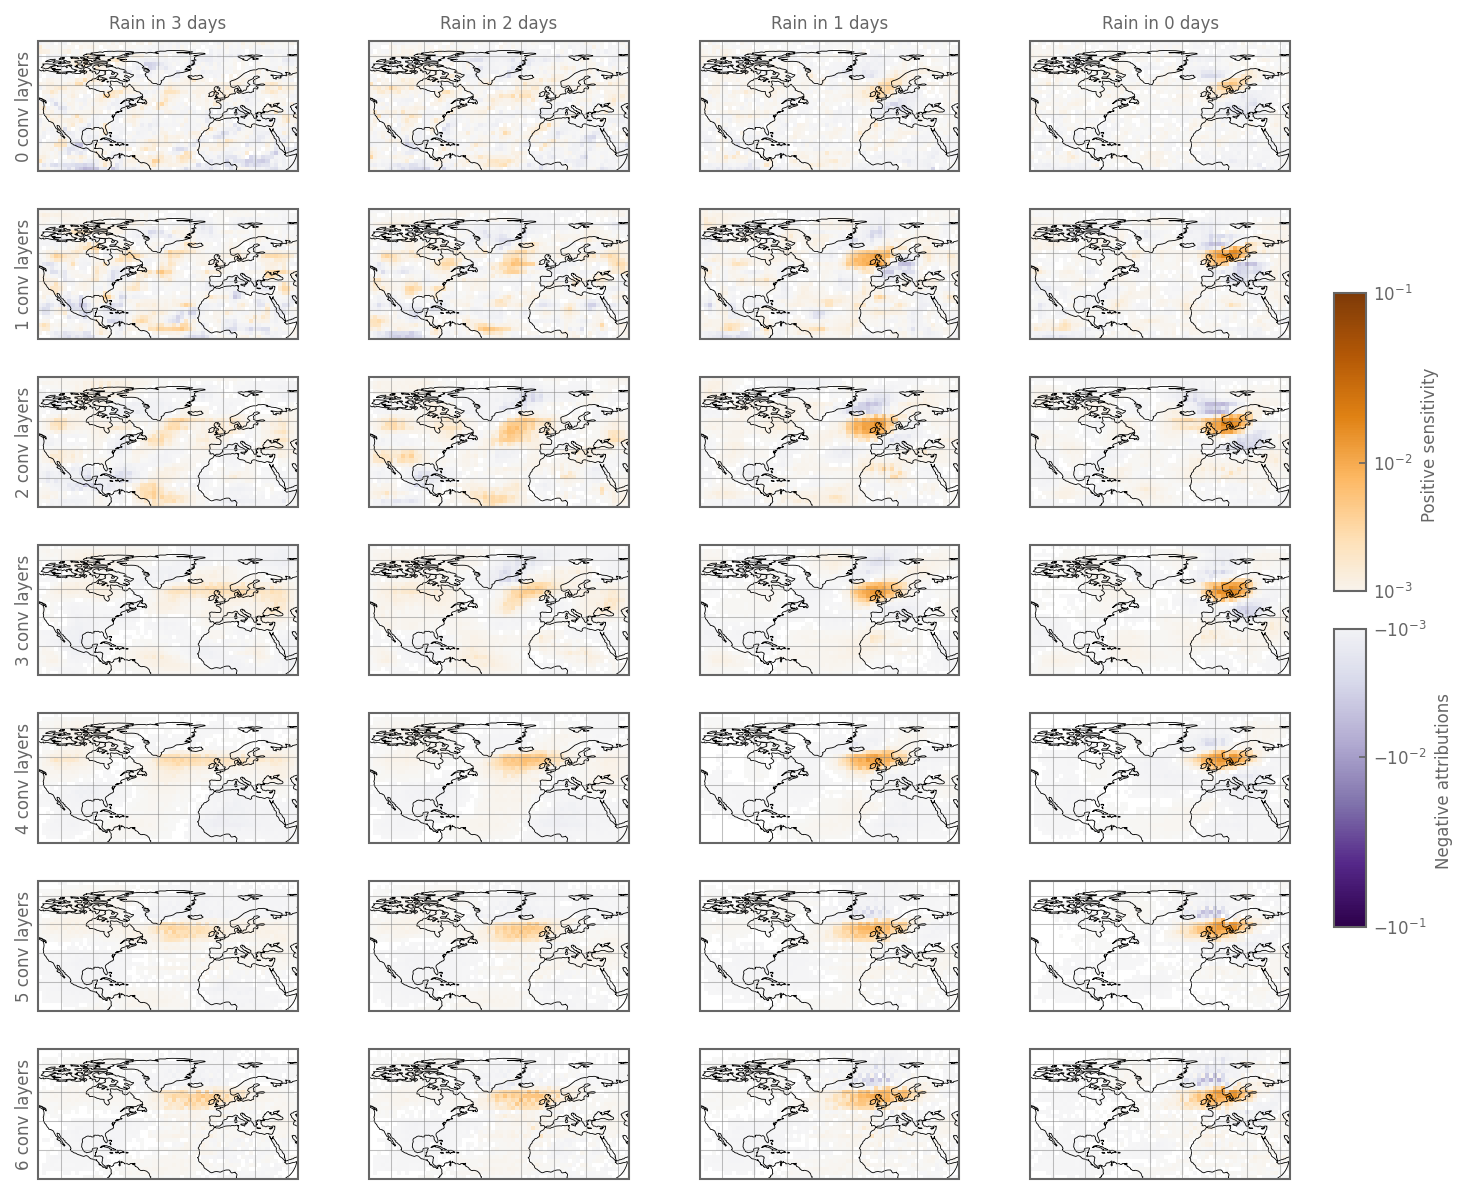

In [59]:

test = ds1.mean('attribution_time').sensitivity.mean('var_name')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
projection = ccrs.PlateCarree(central_longitude=-38)
mosaic = [["A0","B0","C0","D0","."],
          ["A0","B0","C0","D0","."],
          ["A1","B1","C1","D1","."],
          ["A1","B1","C1","D1","cbar1"],
          ["A2","B2","C2","D2","cbar1"],
          ["A2","B2","C2","D2","cbar1"],
          ["A3","B3","C3","D3","cbar1"],
          ["A3","B3","C3","D3","cbar2"],
          ["A4","B4","C4","D4","cbar2"],
          ["A4","B4","C4","D4","cbar2"],
          ["A5","B5","C5","D5","cbar2"],
          ["A5","B5","C5","D5","."],
          ["A6","B6","C6","D6","."],
          ["A6","B6","C6","D6","."],
]
map_kwargs = dict(projection=projection)
map_kwargs = dict(projection=projection)

per_subplot_kw = {k:map_kwargs for k in np.array(mosaic).flatten() if k not in ['cbar1','cbar2','.']}
fig, axs = plt.subplot_mosaic(mosaic,
                              figsize=(10,8),
                              width_ratios = [10,10,10,10,1],
                              per_subplot_kw=per_subplot_kw)
for t, timestep in enumerate(test.timestep):
    for c in test.n_conv_layers.values:
        ax_number = chr(ord("A")+t) + f"{c}"
        ax = axs[ax_number]
        test_extract = test.isel(timestep=t, n_conv_layers=c)
        ax_cbar = axs['cbar1'] if c<3 else axs['cbar2']
        test_extract.where(np.abs(test_extract)>0.0001).plot(ax=ax, transform=ccrs.PlateCarree(),
                                                             norm = matplotlib.colors.SymLogNorm(linthresh=0.002,linscale=.1),
                                                             cmap='PuOr_r', vmax=.1,
                                                             cbar_ax=ax_cbar)
        ax.set_title('')
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='-')
        gl.xlocator = mticker.FixedLocator(np.linspace(-180,180,17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(0,81,20))
        ax.coastlines(linewidth=.4)
        if t==0:
            ax.text(-0.02, 0.5, f"{c} conv layers",  ha='right', va='center',rotation='vertical', fontsize=8, transform=ax.transAxes)        
        if c==0:
            ax.set_title(f"Rain in {3-t} days", size=8)


axs['cbar1'].set_ylim(.001,.1)
axs['cbar2'].set_ylim(-.1,-.001)
axs['cbar1'].set_ylabel("Positive sensitivity ")
axs['cbar2'].set_ylabel("Negative attributions ")

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
# test = test.where(np.abs(test)>1e-3,0)
# plot = test.where(test>0).plot( col='n_conv_layers', row='timestep',
#                  subplot_kws = dict(projection=projection), aspect=1.9, size=2, transform=ccrs.PlateCarree(),
#                 #  norm = matplotlib.colors.SymLogNorm(linthresh=0.002,linscale=.2), 
#                  norm = matplotlib.colors.LogNorm(), 
#                  cmap='mako_r')

# clean_map(plot, boundaries = (-125, 50, 0, 90))
plt.tight_layout()
# test.plot(col='n_conv_layers')

In [94]:
test_extract.where(np.abs(test>0.0001))

<xarray.DataArray 'attributions' (latitude: 32, longitude: 64,
                                  n_conv_layers: 7, timestep: 4)> Size: 229kB
array([[[[           nan,            nan, -3.4323908e-05,
          -3.4323908e-05],
         [           nan,            nan, -3.4323908e-05,
                     nan],
         [           nan,            nan,            nan,
          -3.4323908e-05],
         ...,
         [           nan,            nan,            nan,
                     nan],
         [           nan,            nan,            nan,
                     nan],
         [           nan,            nan,            nan,
                     nan]],

        [[ 2.1115066e-04,            nan,  2.1115066e-04,
           2.1115066e-04],
         [           nan,  2.1115066e-04,  2.1115066e-04,
           2.1115066e-04],
         [           nan,            nan,  2.1115066e-04,
           2.1115066e-04],
...
         [ 9.8506091e-05,            nan,            nan,
                     nan],
         [ 9.8506091e-05,  9.8506091e-05,            nan,
           9.8506091e-05],
         [ 9.8506091e-05,  9.8506091e-05,  9.8506091e-05,
           9.8506091e-05]],

        [[           nan,            nan, -2.4120127e-04,
          -2.4120127e-04],
         [           nan, -2.4120127e-04, -2.4120127e-04,
                     nan],
         [           nan,            nan,            nan,
                     nan],
         ...,
         [-2.4120127e-04, -2.4120127e-04,            nan,
                     nan],
         [-2.4120127e-04, -2.4120127e-04, -2.4120127e-04,
          -2.4120127e-04],
         [-2.4120127e-04, -2.4120127e-04, -2.4120127e-04,
          -2.4120127e-04]]]], dtype=float32)
Coordinates:
  * timestep       (timestep) int64 32B 1 2 3 4
  * latitude       (latitude) float64 256B 1.406 4.219 7.031 ... 85.78 88.59
  * longitude      (longitude) float64 512B -126.6 -123.8 -120.9 ... 47.81 50.62
    mask_id        int64 8B 14
  * n_conv_layers  (n_conv_layers) int64 56B 0 1 2 3 4 5 6

In [73]:
ax

<GeoAxes: label='A0'>